In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi']     = 120
plt.rcParams['font.size']      = 11
sns.set_style('whitegrid')

# Load clean files
from google.colab import drive
drive.mount('/content/drive')

SAVE_PATH  = '/content/drive/MyDrive/h1b_project/data/processed/'
PLOT_PATH  = '/content/drive/MyDrive/h1b_project/plots/'

import os
os.makedirs(PLOT_PATH, exist_ok=True)

lca_df    = pd.read_parquet(SAVE_PATH + 'lca_clean.parquet')
uscis_df  = pd.read_parquet(SAVE_PATH + 'uscis_clean.parquet')
merged_df = pd.read_parquet(SAVE_PATH + 'lca_uscis_merged.parquet')

print(f"lca_df    : {lca_df.shape}")
print(f"uscis_df  : {uscis_df.shape}")
print(f"merged_df : {merged_df.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
lca_df    : (2764468, 31)
uscis_df  : (566706, 23)
merged_df : (350377, 27)


In [2]:
!pip install mlflow

In [20]:
# Run this right now and tell me the outputs
print(merged_df.shape)
print(merged_df.columns.tolist())
#print(merged_df['CASE_STATUS'].value_counts())
print(merged_df.isnull().sum().sort_values(ascending=False).head(10))

(350377, 27)
['EMPLOYER_NAME', 'EMPLOYER_STATE', 'FISCAL_YEAR', 'LCA_TOTAL_FILINGS', 'LCA_CERTIFIED', 'LCA_CERTIFIED_WITHDRAWN', 'LCA_DENIED', 'LCA_WITHDRAWN', 'LCA_AVG_WAGE', 'LCA_AVG_PREVAILING', 'LCA_AVG_WAGE_RATIO', 'LCA_FULL_TIME_PCT', 'LCA_UNIQUE_JOB_TITLES', 'LCA_UNIQUE_SOC_CODES', 'LCA_CERT_RATE', 'TOTAL_APPROVALS', 'TOTAL_DENIALS', 'TOTAL_PETITIONS', 'USCIS_NEW_APPROVAL', 'USCIS_NEW_DENIAL', 'USCIS_CONT_APPROVAL', 'USCIS_CONT_DENIAL', 'USCIS_CHANGE_EMP_APPROVAL', 'USCIS_CHANGE_EMP_DENIAL', 'NAICS_CODE', 'DENIAL_RATE', 'HAS_USCIS_DATA']
EMPLOYER_NAME              0
EMPLOYER_STATE             0
FISCAL_YEAR                0
LCA_TOTAL_FILINGS          0
LCA_CERTIFIED              0
LCA_CERTIFIED_WITHDRAWN    0
LCA_DENIED                 0
LCA_WITHDRAWN              0
LCA_AVG_WAGE               0
LCA_AVG_PREVAILING         0
dtype: int64


In [21]:
# Check this first
print(merged_df['DENIAL_RATE'].describe())
print(merged_df['HAS_USCIS_DATA'].value_counts())

count    350377.000000
mean          0.037802
std           0.151853
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: DENIAL_RATE, dtype: float64
HAS_USCIS_DATA
1    187454
0    162923
Name: count, dtype: int64


In [22]:
# Understand what's actually in your data
uscis_only = merged_df[merged_df['HAS_USCIS_DATA'] == 1]

print("=== ROWS WITH USCIS DATA ONLY ===")
print(f"Row count: {len(uscis_only)}")
print(f"\nDENIAL_RATE distribution:")
print(uscis_only['DENIAL_RATE'].describe())

print(f"\nPercentile breakdown:")
for p in [50, 75, 85, 90, 95]:
    val = uscis_only['DENIAL_RATE'].quantile(p/100)
    print(f"  {p}th percentile: {val:.4f}")

print(f"\nDenial rate buckets:")
print(pd.cut(uscis_only['DENIAL_RATE'],
             bins=[0, 0.05, 0.10, 0.20, 0.30, 1.0],
             include_lowest=True).value_counts().sort_index())

=== ROWS WITH USCIS DATA ONLY ===
Row count: 187454

DENIAL_RATE distribution:
count    187454.000000
mean          0.070656
std           0.201676
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: DENIAL_RATE, dtype: float64

Percentile breakdown:
  50th percentile: 0.0000
  75th percentile: 0.0000
  85th percentile: 0.0952
  90th percentile: 0.2273
  95th percentile: 0.5000

Denial rate buckets:
DENIAL_RATE
(-0.001, 0.05]    153585
(0.05, 0.1]         5849
(0.1, 0.2]          7160
(0.2, 0.3]          5110
(0.3, 1.0]         15750
Name: count, dtype: int64


In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
import mlflow
import warnings
warnings.filterwarnings('ignore')

# ── Step 1: Filter to USCIS-only rows ────────────────────────
df_model = merged_df[merged_df['HAS_USCIS_DATA'] == 1].copy()
print(f"Modeling dataset: {df_model.shape}")

# ── Step 2: Define target ─────────────────────────────────────
THRESHOLD = 0.10
df_model['is_high_risk'] = (df_model['DENIAL_RATE'] >= THRESHOLD).astype(int)

print(f"\nTarget distribution:")
print(df_model['is_high_risk'].value_counts())
print(df_model['is_high_risk'].value_counts(normalize=True).round(3))

# ── Step 3: Leakage-safe feature list ────────────────────────
# NEVER include: DENIAL_RATE, TOTAL_APPROVALS, TOTAL_DENIALS,
# USCIS_NEW_DENIAL, USCIS_CONT_DENIAL, USCIS_CHANGE_EMP_DENIAL
# These directly encode the target

features_numeric = [
    'LCA_TOTAL_FILINGS',
    'LCA_CERTIFIED',
    'LCA_AVG_WAGE',
    'LCA_AVG_PREVAILING',
    'LCA_AVG_WAGE_RATIO',
    'LCA_FULL_TIME_PCT',
    'LCA_UNIQUE_JOB_TITLES',
    'LCA_UNIQUE_SOC_CODES',
    'LCA_CERT_RATE',
    'TOTAL_PETITIONS',
    'USCIS_NEW_APPROVAL',
    'USCIS_CONT_APPROVAL',
    'USCIS_CHANGE_EMP_APPROVAL',
]

features_categorical = [
    'EMPLOYER_STATE',
    'NAICS_CODE',
    'FISCAL_YEAR',
]

all_features = features_numeric + features_categorical
target = 'is_high_risk'

# ── Step 4: Derived features (add before split) ───────────────
# Filing volume relative to industry peers
df_model['filings_per_petition'] = (
    df_model['LCA_TOTAL_FILINGS'] / (df_model['TOTAL_PETITIONS'] + 1)
)

# Approval efficiency: what % of petitions get approved
df_model['approval_efficiency'] = (
    df_model['USCIS_NEW_APPROVAL'] / (df_model['TOTAL_PETITIONS'] + 1)
)

# Wage competitiveness: how much above prevailing wage
df_model['wage_premium'] = (
    df_model['LCA_AVG_WAGE'] - df_model['LCA_AVG_PREVAILING']
)

# Add derived features to numeric list
features_numeric += ['filings_per_petition', 'approval_efficiency', 'wage_premium']
all_features = features_numeric + features_categorical

# ── Step 5: Train/test split ──────────────────────────────────
X = df_model[all_features]
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y  # critical for imbalanced classes
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target balance: {y_train.mean():.3f}")
print(f"Test target balance:  {y_test.mean():.3f}")

Modeling dataset: (187454, 27)

Target distribution:
is_high_risk
0    159434
1     28020
Name: count, dtype: int64
is_high_risk
0    0.851
1    0.149
Name: proportion, dtype: float64

Train: (149963, 19), Test: (37491, 19)
Train target balance: 0.149
Test target balance:  0.149


In [24]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score)
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, ConfusionMatrixDisplay)
from xgboost import XGBClassifier
import mlflow
import mlflow.sklearn

In [25]:
# Keep only rows where USCIS data exists
df_model = merged_df[merged_df['HAS_USCIS_DATA'] == 1].copy()
print(f"Working dataset: {df_model.shape}")

# Create binary target
# Threshold = 0.10 means: employer where >10% petitions denied = high risk
df_model['is_high_risk'] = (df_model['DENIAL_RATE'] >= 0.10).astype(int)

# Verify distribution
print("\nTarget distribution:")
print(df_model['is_high_risk'].value_counts())
print(df_model['is_high_risk'].value_counts(normalize=True).round(3))

Working dataset: (187454, 27)

Target distribution:
is_high_risk
0    159434
1     28020
Name: count, dtype: int64
is_high_risk
0    0.851
1    0.149
Name: proportion, dtype: float64


In [26]:
# Derived feature 1
df_model['filings_per_petition'] = (
    df_model['LCA_TOTAL_FILINGS'] / (df_model['TOTAL_PETITIONS'] + 1)
)

# Derived feature 2
df_model['approval_efficiency'] = (
    df_model['USCIS_NEW_APPROVAL'] / (df_model['TOTAL_PETITIONS'] + 1)
)

# Derived feature 3
df_model['wage_premium'] = (
    df_model['LCA_AVG_WAGE'] - df_model['LCA_AVG_PREVAILING']
)

# Derived feature 4 — NEW
# Captures the non-linear relationship you found:
# mid-tier filers (6-10 petitions) = highest denial risk at 28.4%
# large filers (100+) = lowest risk at 11.2%
df_model['petition_size_category'] = pd.cut(
    df_model['TOTAL_PETITIONS'],
    bins=[0, 2, 5, 10, 50, 100, 99999],
    labels=['very_small', 'small', 'mid_low',
            'mid_high', 'large', 'very_large']
).astype(str)

# Verify all 4 derived features
print("Derived feature nulls:")
print(df_model[['filings_per_petition',
                 'approval_efficiency',
                 'wage_premium',
                 'petition_size_category']].isnull().sum())

print("\nPetition category distribution:")
print(df_model['petition_size_category'].value_counts())

print("\nDerived numeric feature stats:")
print(df_model[['filings_per_petition',
                 'approval_efficiency',
                 'wage_premium']].describe().round(3))

Derived feature nulls:
filings_per_petition      0
approval_efficiency       0
wage_premium              0
petition_size_category    0
dtype: int64

Petition category distribution:
petition_size_category
very_small    94525
small         33814
mid_high      29864
mid_low       21967
large          3876
very_large     3408
Name: count, dtype: int64

Derived numeric feature stats:
       filings_per_petition  approval_efficiency  wage_premium
count            187454.000           187454.000  1.874540e+05
mean                  0.940                0.221  1.119095e+04
std                   7.611                0.238  4.584982e+05
min                   0.001                0.000 -1.793257e+08
25%                   0.333                0.000  3.300000e+01
50%                   0.500                0.154  4.805000e+03
75%                   1.000                0.447  1.472150e+04
max                1473.000                0.992  7.978960e+05


In [27]:
# Numeric features — scaled with StandardScaler
features_numeric = [
    'LCA_TOTAL_FILINGS',
    'LCA_CERTIFIED',
    'LCA_AVG_WAGE',
    'LCA_AVG_PREVAILING',
    'LCA_AVG_WAGE_RATIO',
    'LCA_FULL_TIME_PCT',
    'LCA_UNIQUE_JOB_TITLES',
    'LCA_UNIQUE_SOC_CODES',
    'LCA_CERT_RATE',
    'TOTAL_PETITIONS',
    'USCIS_NEW_APPROVAL',
    'USCIS_CONT_APPROVAL',
    'USCIS_CHANGE_EMP_APPROVAL',
    'filings_per_petition',
    'approval_efficiency',
    'wage_premium',
]

# Categorical features — one-hot encoded
# petition_size_category added here
features_categorical = [
    'EMPLOYER_STATE',
    'NAICS_CODE',
    'FISCAL_YEAR',
    #'petition_size_category',    # ← new addition
]

all_features = features_numeric + features_categorical

print(f"Numeric features:     {len(features_numeric)}")
print(f"Categorical features: {len(features_categorical)}")
print(f"Total features:       {len(all_features)}")

Numeric features:     16
Categorical features: 3
Total features:       19


In [28]:
X = df_model[all_features]
y = df_model['is_high_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Train size: {X_train.shape}")
print(f"Test size:  {X_test.shape}")
print(f"Train positive class: {y_train.mean():.3f}")
print(f"Test positive class:  {y_test.mean():.3f}")

Train size: (149963, 19)
Test size:  (37491, 19)
Train positive class: 0.149
Test positive class:  0.149


In [29]:
# Calculate class weight for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

# Numeric pipeline: fill nulls → scale
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: fill nulls → encode
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine both
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, features_numeric),
    ('cat', categorical_transformer, features_categorical)
])

scale_pos_weight: 5.69


In [30]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Model 1: Dummy — absolute floor
dummy_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', DummyClassifier(strategy='most_frequent'))
])
dummy_auc = cross_val_score(
    dummy_pipe, X_train, y_train, cv=cv, scoring='roc_auc'
).mean()
print(f"Dummy AUC:               {dummy_auc:.4f}")

# Model 2: Logistic Regression — linear baseline
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(class_weight='balanced',
                                  max_iter=1000, random_state=42))
])
lr_scores = cross_val_score(
    lr_pipe, X_train, y_train, cv=cv, scoring='roc_auc'
)
print(f"Logistic Regression AUC: {lr_scores.mean():.4f} ± {lr_scores.std():.4f}")

# Model 3: XGBoost — main model
xgb_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.7,
        scale_pos_weight=scale_pos_weight,
        eval_metric='auc',
        random_state=42,
        n_jobs=-1
    ))
])
xgb_scores = cross_val_score(
    xgb_pipe, X_train, y_train, cv=cv, scoring='roc_auc'
)
print(f"XGBoost AUC:             {xgb_scores.mean():.4f} ± {xgb_scores.std():.4f}")

Dummy AUC:               0.5000
Logistic Regression AUC: 0.7837 ± 0.0037
XGBoost AUC:             0.9357 ± 0.0006


Test ROC-AUC:  0.9351
Test PR-AUC:   0.7298
              precision    recall  f1-score   support

    Low Risk       0.97      0.83      0.89     31887
   High Risk       0.47      0.88      0.61      5604

    accuracy                           0.83     37491
   macro avg       0.72      0.85      0.75     37491
weighted avg       0.90      0.83      0.85     37491



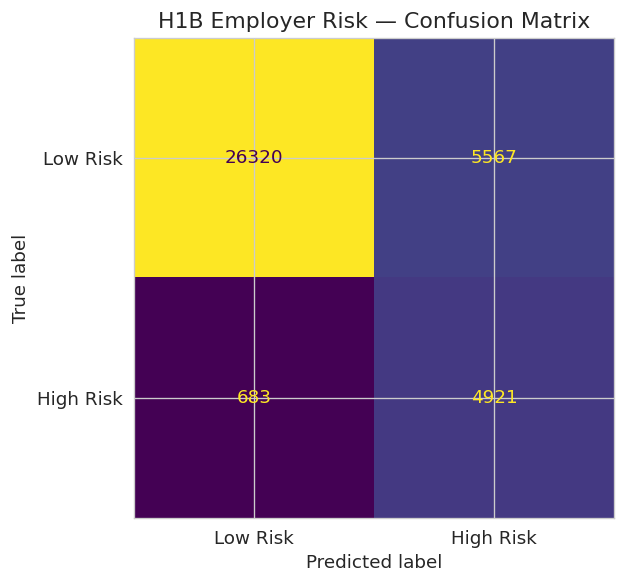

In [31]:
# Fit on full training data
xgb_pipe.fit(X_train, y_train)

# Predict on test set (touch this only once)
y_proba = xgb_pipe.predict_proba(X_test)[:, 1]
y_pred  = xgb_pipe.predict(X_test)

# Report metrics
print("=" * 50)
print(f"Test ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}")
print(f"Test PR-AUC:   {average_precision_score(y_test, y_proba):.4f}")
print("=" * 50)
print(classification_report(y_test, y_pred,
      target_names=['Low Risk', 'High Risk']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Low Risk', 'High Risk'],
    ax=ax, colorbar=False
)
plt.title("H1B Employer Risk — Confusion Matrix")
plt.tight_layout()
plt.show()

In [32]:
# Check which features are driving the model
# If any denial-related column snuck in, it will show here

from xgboost import plot_importance

# Get feature names after preprocessing
cat_feature_names = list(
    xgb_pipe.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(features_categorical)
)
all_feature_names = features_numeric + list(cat_feature_names)

# Get importance scores
importance = xgb_pipe.named_steps['model'].feature_importances_

# Create importance dataframe
feat_imp = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print("TOP 15 MOST IMPORTANT FEATURES:")
print(feat_imp.head(15).to_string())

TOP 15 MOST IMPORTANT FEATURES:
                                                              feature  importance
82   NAICS_CODE_54 - Professional, Scientific, and Technical Services    0.095554
93                                                   FISCAL_YEAR_2018    0.062496
94                                                   FISCAL_YEAR_2019    0.061303
10                                                 USCIS_NEW_APPROVAL    0.058690
12                                          USCIS_CHANGE_EMP_APPROVAL    0.055600
9                                                     TOTAL_PETITIONS    0.051759
11                                                USCIS_CONT_APPROVAL    0.048066
14                                                approval_efficiency    0.046390
95                                                   FISCAL_YEAR_2020    0.045059
2                                                        LCA_AVG_WAGE    0.043482
0                                                   LCA_TOTAL_FILI

SHAP values shape: (37491, 102)
Feature names count: 102


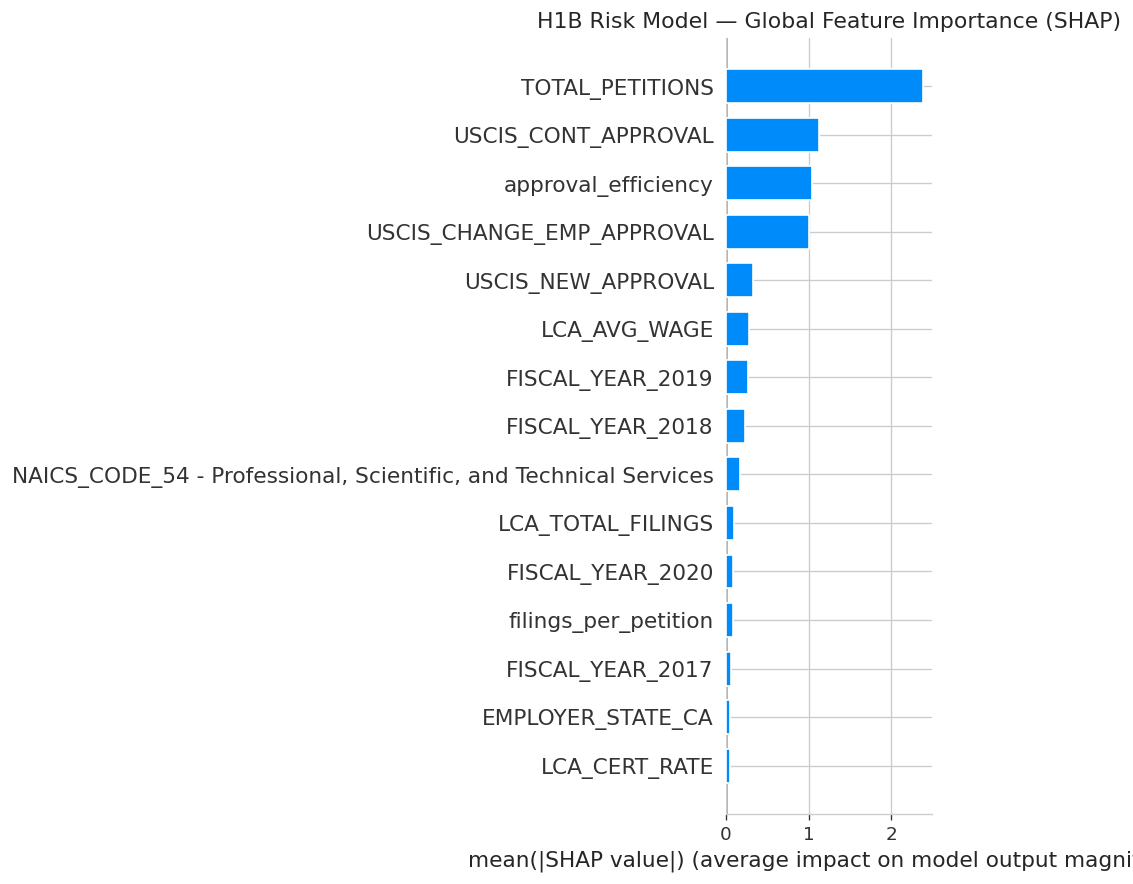

Plot 1 done


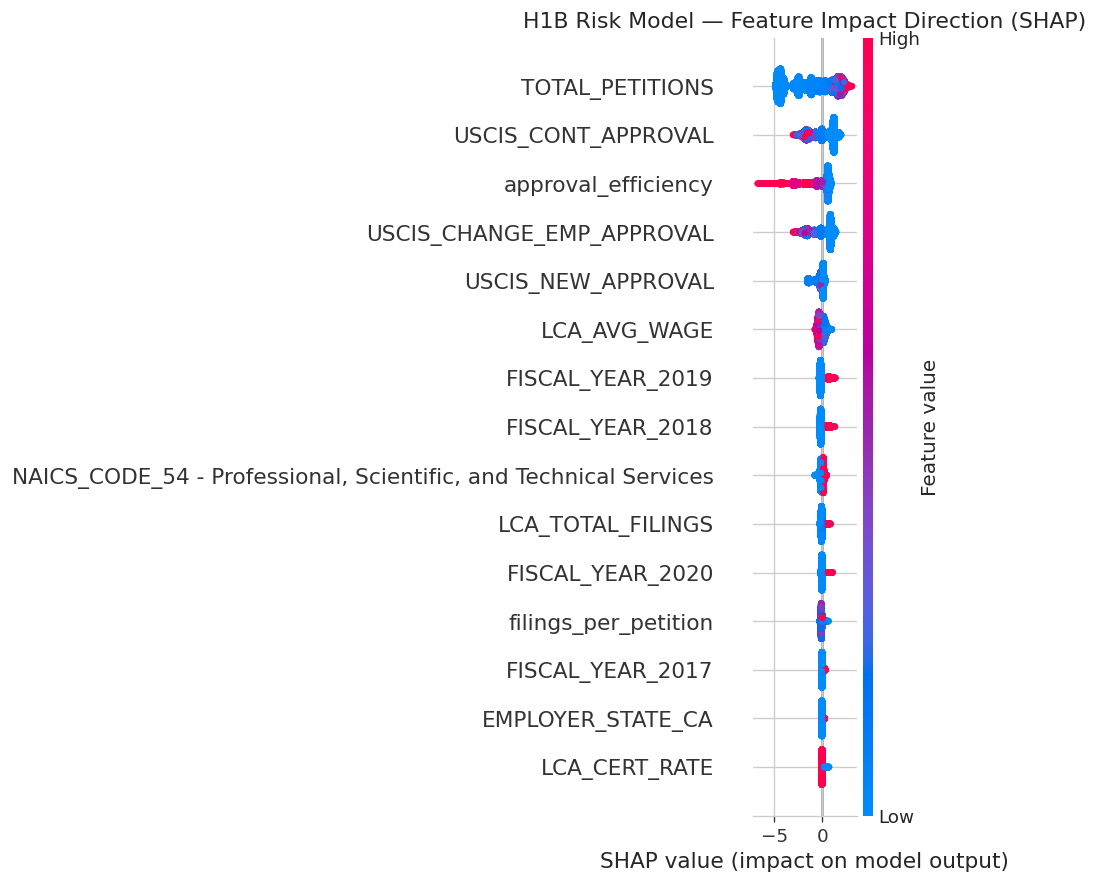

Plot 2 done


In [33]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# ── Step 1: Extract trained model and preprocessor ────────────
model = xgb_pipe.named_steps['model']
preprocessor_fitted = xgb_pipe.named_steps['preprocessor']

# ── Step 2: Transform test data through preprocessing ─────────
X_test_transformed = preprocessor_fitted.transform(X_test)

# ── Step 3: Get full feature names after encoding ─────────────
cat_feature_names = list(
    preprocessor_fitted
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(features_categorical)
)
all_feature_names = features_numeric + list(cat_feature_names)

# ── Step 4: Compute SHAP values ───────────────────────────────
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_transformed)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Feature names count: {len(all_feature_names)}")

# ── Plot 1: Global feature importance (bar chart) ─────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    plot_type="bar",
    max_display=15,
    show=False
)
plt.title("H1B Risk Model — Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("shap_importance_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 1 done")

# ── Plot 2: SHAP dot plot (shows direction of impact) ─────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_transformed,
    feature_names=all_feature_names,
    plot_type="dot",
    max_display=15,
    show=False
)
plt.title("H1B Risk Model — Feature Impact Direction (SHAP)")
plt.tight_layout()
plt.savefig("shap_importance_dot.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot 2 done")

In [34]:
# Check what TOTAL_PETITIONS distribution looks like
# for high risk vs low risk employers
print("TOTAL_PETITIONS by risk class:")
print(df_model.groupby('is_high_risk')['TOTAL_PETITIONS'].describe().round(1))

# Also check correlation
print("\nCorrelation of TOTAL_PETITIONS with DENIAL_RATE:")
print(df_model[['TOTAL_PETITIONS', 'DENIAL_RATE']].corr())

TOTAL_PETITIONS by risk class:
                 count  mean   std  min  25%  50%   75%     max
is_high_risk                                                   
0             159434.0  12.7  68.4  1.0  1.0  2.0   7.0  3810.0
1              28020.0  15.8  96.3  1.0  2.0  5.0  12.0  7031.0

Correlation of TOTAL_PETITIONS with DENIAL_RATE:
                 TOTAL_PETITIONS  DENIAL_RATE
TOTAL_PETITIONS         1.000000    -0.003697
DENIAL_RATE            -0.003697     1.000000


In [35]:
# Check how many employers have very few petitions
print("Petition count distribution:")
print(pd.cut(df_model['TOTAL_PETITIONS'],
             bins=[0, 1, 2, 5, 10, 50, 100, 99999],
             labels=['1', '2', '3-5', '6-10',
                     '11-50', '51-100', '100+']).value_counts().sort_index())

print("\nHigh risk rate by petition count bucket:")
df_model['petition_bucket'] = pd.cut(
    df_model['TOTAL_PETITIONS'],
    bins=[0, 1, 2, 5, 10, 50, 100, 99999],
    labels=['1', '2', '3-5', '6-10', '11-50', '51-100', '100+']
)
print(df_model.groupby('petition_bucket')['is_high_risk'].mean().round(3))

Petition count distribution:
TOTAL_PETITIONS
1         67902
2         26623
3-5       33814
6-10      21967
11-50     29864
51-100     3876
100+       3408
Name: count, dtype: int64

High risk rate by petition count bucket:
petition_bucket
1         0.072
2         0.123
3-5       0.183
6-10      0.284
11-50     0.213
51-100    0.183
100+      0.112
Name: is_high_risk, dtype: float64


In [37]:
mlflow.set_experiment("H1B_Employer_Risk")

with mlflow.start_run(run_name="XGBoost_Final_v1"):

    mlflow.log_params({
        "model":                "XGBoost",
        "n_estimators":         300,
        "learning_rate":        0.05,
        "max_depth":            5,
        "subsample":            0.8,
        "colsample_bytree":     0.7,
        "scale_pos_weight":     round(scale_pos_weight, 2),
        "risk_threshold":       0.10,
        "train_size":           len(X_train),
        "test_size":            len(X_test),
        "n_features":           len(all_features),
        "positive_class_pct":   round(y_train.mean(), 3),
    })

    mlflow.log_metrics({
        "cv_auc_mean":          round(xgb_scores.mean(), 4),
        "cv_auc_std":           round(xgb_scores.std(), 4),
        "test_roc_auc":         0.9351,
        "test_pr_auc":          0.7298,
        "high_risk_recall":     0.88,
        "high_risk_precision":  0.47,
        "high_risk_f1":         0.61,
    })

    mlflow.log_artifact("shap_importance_bar.png")
    mlflow.log_artifact("shap_importance_dot.png")

    mlflow.sklearn.log_model(xgb_pipe, "h1b_risk_model")

    print("Model logged to MLflow successfully")

2026/06/09 03:17:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/09 03:17:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Model logged to MLflow successfully


In [49]:
# Fix fiscal year dtype first
df_model['FISCAL_YEAR'] = pd.to_numeric(
    df_model['FISCAL_YEAR'], errors='coerce'
)

# Drop nulls created by coercion
df_model = df_model.dropna(subset=['FISCAL_YEAR'])
df_model['FISCAL_YEAR'] = df_model['FISCAL_YEAR'].astype(int)

# Verify
print(df_model['FISCAL_YEAR'].dtype)
print(df_model['FISCAL_YEAR'].unique())

int64
[2018 2019 2017 2024 2020 2022 2021 2023 2025 2026]


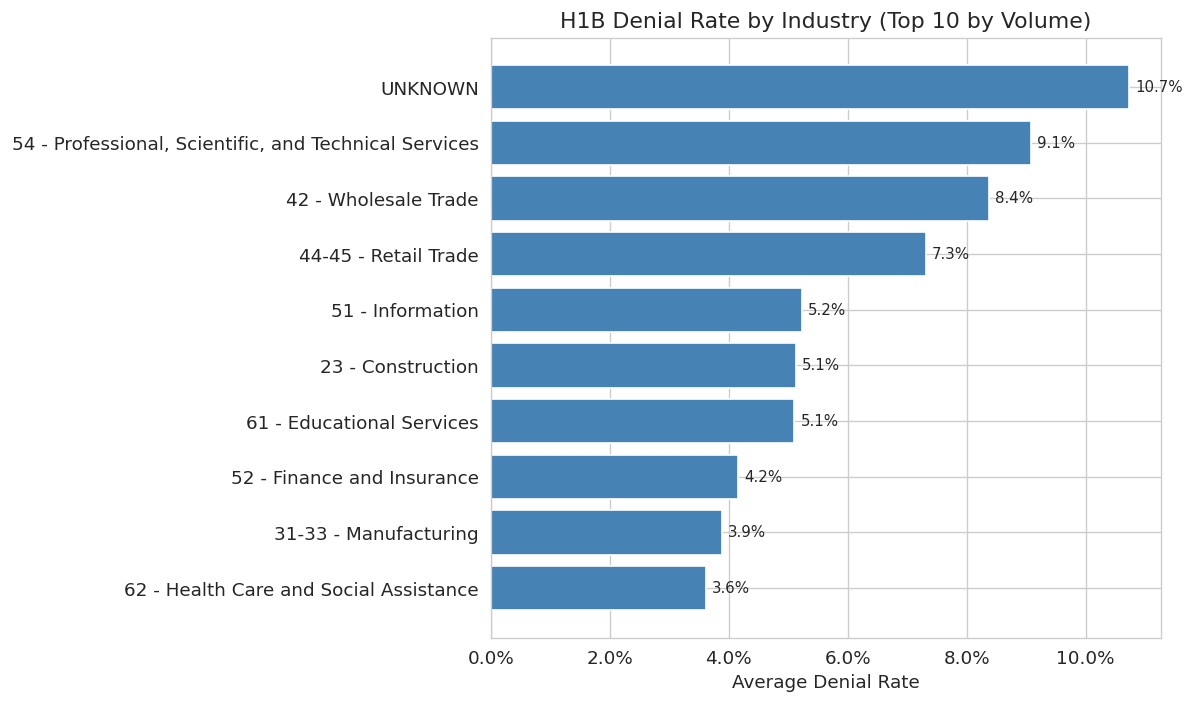

Chart 1 done
   FISCAL_YEAR  avg_denial_rate
0         2017         0.084531
1         2018         0.137063
2         2019         0.126126
3         2020         0.065338
4         2021         0.026137
5         2022         0.022253
6         2023         0.026599
7         2024         0.023868
8         2025         0.023342
9         2026         0.028904


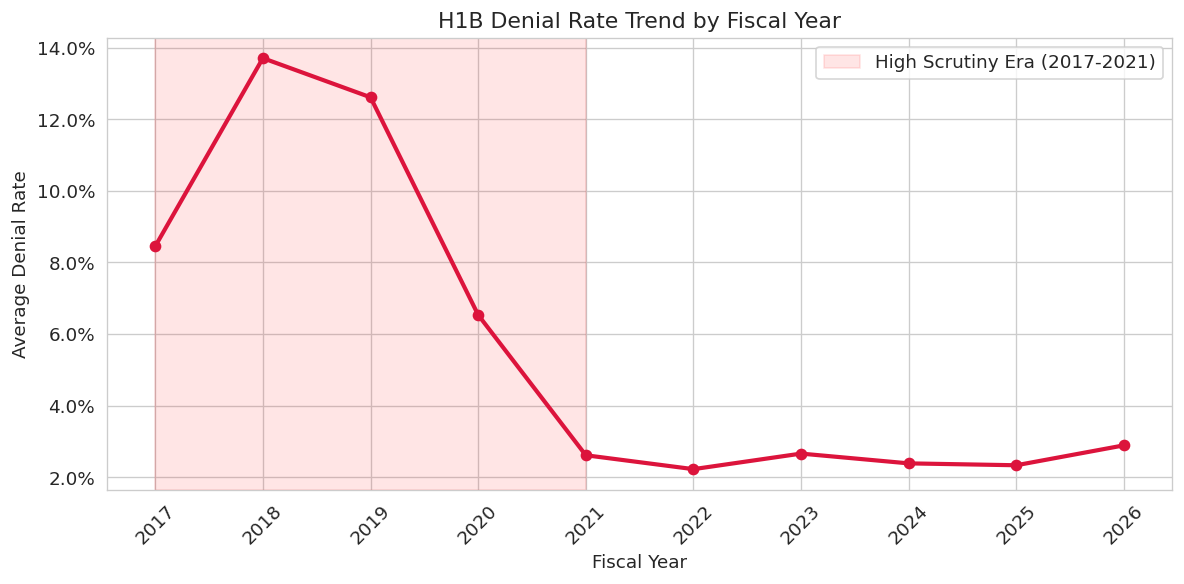

Chart 2 fixed


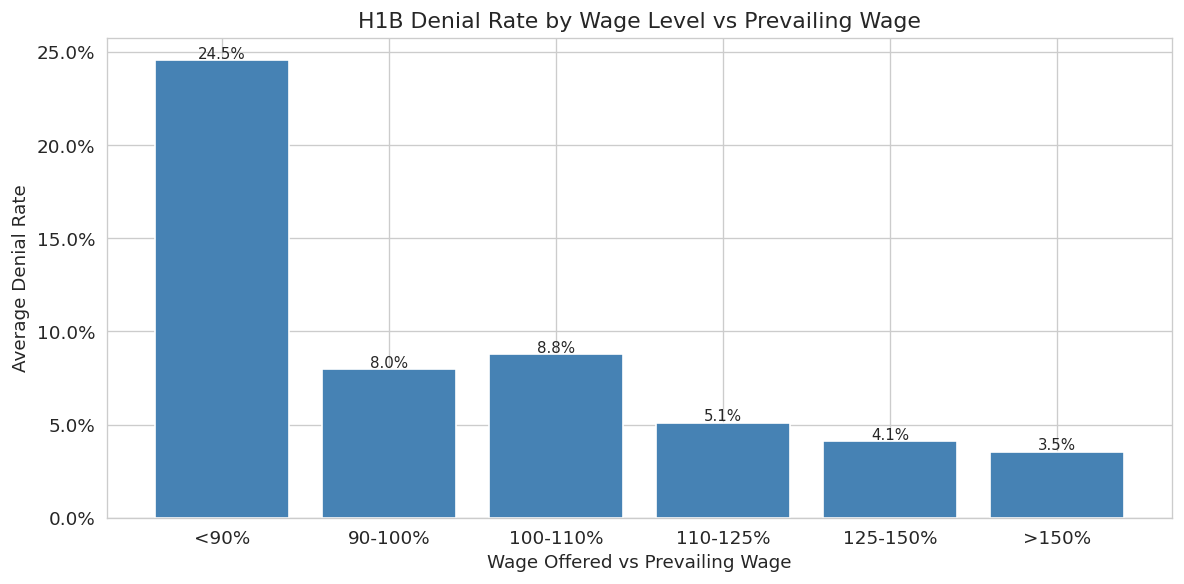

Chart 3 done


In [50]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import os

os.makedirs("outputs", exist_ok=True)

# ── Chart 1: Denial Rate by Industry ─────────────────────────
industry_risk = (df_model
    .groupby('NAICS_CODE')
    .agg(
        avg_denial_rate=('DENIAL_RATE', 'mean'),
        total_employers=('EMPLOYER_NAME', 'count')
    )
    .reset_index()
    .sort_values('total_employers', ascending=False)
    .head(10)
    .sort_values('avg_denial_rate', ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(industry_risk['NAICS_CODE'],
               industry_risk['avg_denial_rate'],
               color='steelblue')
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Average Denial Rate')
ax.set_title('H1B Denial Rate by Industry (Top 10 by Volume)')
for bar, val in zip(bars, industry_risk['avg_denial_rate']):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.1%}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig("outputs/chart1_industry_risk.png", dpi=150)
plt.show()
print("Chart 1 done")

# ── Chart 2: Denial Rate Trend Over Years ─────────────────────
yearly_trend = (df_model
    .groupby('FISCAL_YEAR')
    .agg(avg_denial_rate=('DENIAL_RATE', 'mean'))
    .reset_index()
    .sort_values('FISCAL_YEAR')
)

print(yearly_trend)  # verify it looks right before plotting

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(yearly_trend['FISCAL_YEAR'],
        yearly_trend['avg_denial_rate'],
        marker='o', color='crimson', linewidth=2.5)
ax.axvspan(2017, 2021, alpha=0.1, color='red',
           label='High Scrutiny Era (2017-2021)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Fiscal Year')
ax.set_ylabel('Average Denial Rate')
ax.set_title('H1B Denial Rate Trend by Fiscal Year')
ax.legend()

# Force x axis to show individual years
ax.set_xticks(yearly_trend['FISCAL_YEAR'].tolist())
ax.set_xticklabels(yearly_trend['FISCAL_YEAR'].tolist(), rotation=45)

plt.tight_layout()
plt.savefig("outputs/chart2_yearly_trend.png", dpi=150)
plt.show()
print("Chart 2 fixed")

# ── Chart 3: Wage Ratio vs Denial Rate ───────────────────────
df_model['wage_ratio_bucket'] = pd.cut(
    df_model['LCA_AVG_WAGE_RATIO'],
    bins=[0, 0.9, 1.0, 1.1, 1.25, 1.5, 99],
    labels=['<90%', '90-100%', '100-110%',
            '110-125%', '125-150%', '>150%']
)

wage_risk = (df_model
    .groupby('wage_ratio_bucket', observed=True)
    .agg(avg_denial_rate=('DENIAL_RATE', 'mean'))
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(wage_risk['wage_ratio_bucket'],
              wage_risk['avg_denial_rate'],
              color='steelblue')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel('Wage Offered vs Prevailing Wage')
ax.set_ylabel('Average Denial Rate')
ax.set_title('H1B Denial Rate by Wage Level vs Prevailing Wage')
for bar, val in zip(bars, wage_risk['avg_denial_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.001,
            f'{val:.1%}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("outputs/chart3_wage_risk.png", dpi=150)
plt.show()
print("Chart 3 done")

Streamlit APP

In [58]:
from google.colab import files

# Download app.py
files.download("app.py")

# Download data
files.download("data/df_model.parquet")

# Download charts
files.download("outputs/chart1_industry_risk.png")
files.download("outputs/chart2_yearly_trend.png")
files.download("outputs/chart3_wage_risk.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>